# MLPC 2026 — Task 3: Subtask 2 — Annotations

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations

plt.rcParams['figure.dpi'] = 100

In [10]:
DATA_DIR      = Path('../data')
FEATURES_DIR  = DATA_DIR / 'audio_features'

annotations_df = pd.read_csv(DATA_DIR / 'annotations.csv')
metadata_df    = pd.read_csv(DATA_DIR / 'metadata.csv')

print(f'annotations.csv : {len(annotations_df)} rows, {annotations_df["filename"].nunique()} unique files')
print(f'metadata.csv    : {len(metadata_df)} rows')
annotations_df.head()

annotations.csv : 37419 rows, 3656 unique files
metadata.csv    : 3656 rows


,filename,annotator_id,annotation,onset,offset,is_own_recording
0,000112.wav,2190518039615423109192646528977018723001939610...,footsteps,13.060211,13.315831,False
1,000695.wav,4496809211053681637690999252976315563042618669...,door_open_close,1.508440,2.061877,False
2,000488.wav,7535443191697509271271535104115945129183028445...,microwave,4.833705,25.929958,True
3,005087.wav,4496809211053681637690999252976315563042618669...,keyboard_typing,0.337356,18.230374,False
4,005465.wav,7618427328765435143030208879017391647684958822...,running_water,5.254437,15.088430,True


In [11]:
# Load all .npz feature files
# Each file holds pre-computed features + time-aligned annotations for one recording
def load_npz(path):
    return dict(np.load(path, allow_pickle=True))

npz_files = {f.stem: load_npz(f) for f in sorted(FEATURES_DIR.glob('*.npz'))}
print(f'Loaded {len(npz_files)} NPZ files')

Loaded 3656 NPZ files


In [12]:
# Inspect the structure of one file so we know what we are working with
key     = sorted(npz_files.keys())[0]
sample  = npz_files[key]

print('File:', key)
print('Keys available:', list(sample.keys()))
print()
print('annotations shape (T, C, A):', sample['annotations'].shape)
print('  T = number of 1-second time segments')
print('  C = number of sound classes')
print('  A = number of annotators for this recording')
print()
print('class_names     :', sample['class_names'])
print('target_classes  :', sample['target_classes'])
print('is_own_recording:', sample['is_own_recording'])

File: 000001
Keys available: ['zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max', 'start_time', 'end_time', 'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max', 'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max', 'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max', 'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max', 'flux_mean', 'flux_std', 'flux_min', 'flux_max', 'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max', 'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max', 'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max', 'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max', 'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max', 'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max', 'energy_mean', 'energy_std', 'energy_min', 'energy_max', 'power_mean', 'power_std', 'power_min', 'power_max', 'annotations', 'is_own_recording', 'class_names', 'annotator_ids', 'target_classes', '

In [13]:
# Verify actual time segment duration
starts    = sample['start_time']
ends      = sample['end_time']
durations = ends - starts

print('First 5 start times:', starts[:5])
print('First 5 end times:  ', ends[:5])
print('Unique segment durations:', np.unique(durations.round(4)))
print(f'Total recording length: {ends[-1]:.1f}s  ({len(starts)} segments)')

First 5 start times: [0.  0.5 1.  1.5 2. ]
First 5 end times:   [1.  1.5 2.  2.5 3. ]
Unique segment durations: [1.]
Total recording length: 31.0s  (61 segments)


In [ ]:
# 2a — Pairwise annotator agreement
# One row per (recording, annotator pair, class)
rows = []

for fname, data in npz_files.items():
    ann         = data['annotations']   # [T, C, A]
    A           = ann.shape[2]
    class_names = data['class_names']

    for i, j in combinations(range(A), 2):
        #since there are values inside (0, 1) I use the difference
        #bigger the difference, smaller the agreements
        agree_per_class = 1 - np.abs(ann[:, :, i] - ann[:, :, j]).mean(axis=0)  # [C]
        for c, cls in enumerate(class_names):
            rows.append({
                'filename'  : fname,
                'class'     : cls,
                'agreement' : agree_per_class[c],
            })

agreement_df = pd.DataFrame(rows)
print(f'Total rows: {len(agreement_df)}')
agreement_df.head(16)

Total rows: 86025


,filename,class,agreement
0,000001,bell_ringing,1.000000
1,000001,coffee_machine,1.000000
2,000001,cutlery_dishes,1.000000
3,000001,door_open_close,1.000000
4,000001,footsteps,1.000000
5,000001,keyboard_typing,0.835541
6,000001,keychain,1.000000
7,000001,light_switch,1.000000
8,000001,microwave,1.000000
9,000001,phone_ringing,0.934639


In [18]:
sample_ann = npz_files['000001']['annotations']
print('Unique values:', np.unique(sample_ann))

Unique values: [0.         0.11946398 0.13746502 0.3093095  0.344      0.34699386
 0.35761318 0.35867667 0.37469462 0.3762469  0.3805103  0.3808066
 0.4130864  0.4864033  0.5093004  0.5909183  0.619464   0.637465
 0.8093095  0.844      0.84699386 0.85761315 0.8586767  0.87469465
 0.8762469  0.8805103  0.88080657 0.90813166 0.9130864  0.9311934
 0.9864033  1.        ]


In [21]:
sample_ann = npz_files['000009']['annotations']
total = sample_ann.size
print(f'Total values   : {total}')
print(f'Exactly 0.0    : {(sample_ann == 0).sum()}')
print(f'Exactly 1.0    : {(sample_ann == 1).sum()}')
print(f'Fractional     : {((sample_ann > 0) & (sample_ann < 1)).sum()}')

Total values   : 2310
Exactly 0.0    : 2284
Exactly 1.0    : 5
Fractional     : 21


In [22]:
# Mean agreement per class across all recordings and annotator pairs
class_agreement = (agreement_df
                   .groupby('class')['agreement']
                   .mean()
                   .sort_values())

print(class_agreement.round(4).to_string())
print(f'\nOverall mean agreement: {class_agreement.mean():.4f}')

class
footsteps                     0.9290
door_open_close               0.9681
cutlery_dishes                0.9730
keychain                      0.9781
running_water                 0.9781
keyboard_typing               0.9805
phone_ringing                 0.9830
wardrobe_drawer_open_close    0.9837
microwave                     0.9843
toilet_flushing               0.9858
window_open_close             0.9898
vacuum_cleaner                0.9915
light_switch                  0.9925
coffee_machine                0.9932
bell_ringing                  0.9940

Overall mean agreement: 0.9803


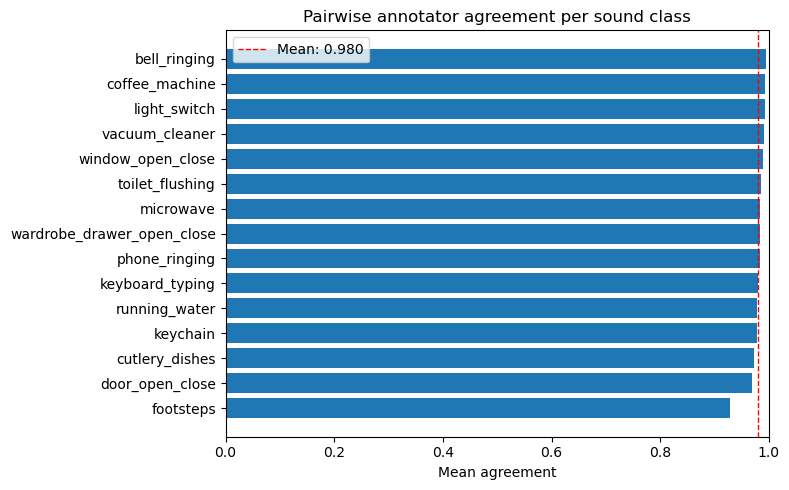

In [23]:
# Bar chart — mean annotator agreement per sound class
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(class_agreement.index, class_agreement.values)
ax.axvline(class_agreement.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {class_agreement.mean():.3f}')
ax.set_xlabel('Mean agreement')
ax.set_title('Pairwise annotator agreement per sound class')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

In [29]:
# Annotator count distribution and owner fraction analysis
annotator_counts = {fname: data['annotations'].shape[2] for fname, data in npz_files.items()}
max_A    = max(annotator_counts.values())
max_file = max(annotator_counts, key=annotator_counts.get)

print(f'Max annotators: {max_A}  (recording {max_file})')
print(f'Min owner fraction (at A={max_A}): {2/max_A:.1%}')
print()

print('Distribution of annotator counts:')
counts_series = pd.Series(annotator_counts).value_counts().sort_index()
for n, c in counts_series.items():
    print(f'  A={n}: {c} recordings')
print()

# Check for recordings without an owner and compute mean owner pairs fraction
owner_fractions = []
no_owner = 0
for fname, data in npz_files.items():
    A        = data['annotations'].shape[2]
    has_owner = data['is_own_recording'].any()
    if has_owner:
        owner_fractions.append(2 / A)
    else:
        no_owner += 1
        owner_fractions.append(0.0)

print(f'Recordings without an owner annotator: {no_owner}')
print(f'Mean owner pairs fraction across all recordings: {np.mean(owner_fractions):.1%}')

Max annotators: 5  (recording 000015)
Min owner fraction (at A=5): 40.0%

Distribution of annotator counts:
  A=1: 625 recordings
  A=2: 1750 recordings
  A=3: 1235 recordings
  A=4: 45 recordings
  A=5: 1 recordings

Recordings without an owner annotator: 447
Mean owner pairs fraction across all recordings: 85.7%


## 2b — Convert Annotations to Labels

**Goal:** collapse `[T, C, A]` annotations into a binary `[T, C]` label matrix per recording.

### Aggregation: owner-weighted mean
Owner annotator (`is_own_recording=True`) gets weight **2**, others get weight **1**.  
Assumption: the collector of the recording knows its contents better than external annotators.

The aggregated value for a segment is:

$$\text{agg}(t,c) = \frac{2 \cdot a_{own}(t,c) + \sum_{k \neq own} a_k(t,c)}{2 + (A - 1)}$$

Weight=2 was chosen as a conservative boost — "owner counts double" rather than "owner is always right."  
In the most common case (A=2, 1750 recordings), the owner holds $\frac{2}{2+1} = \frac{2}{3} \approx 66.7\%$ of the vote: a strong advantage but not absolute.

Weight=2 is also the exact boundary for the second most common case (A=3, 1235 recordings):

$$\frac{w}{w + 2} = 0.5 \implies w = 2$$

With three annotators the owner is placed exactly at the threshold — a single disagreeing external annotator is not enough to override them, but two external annotators disagreeing together are, since their combined opinion is more reliable than one person's alone.

For $A \geq 4$, a sufficient majority of external annotators can outvote the owner, since:

$$\frac{2}{2 + (A-1)} = \frac{2}{A+1} < 0.5 \iff A > 3$$

At the maximum observed $A=5$, the owner's share drops to $\frac{2}{6} \approx 33\%$ — three external annotators agreeing are enough to override them.  
Making the owner infallible would require weight $\geq A - 1$, which at $A=5$ means weight $\geq 4$, rendering all other annotations irrelevant.

### Binarization: threshold at 0.5
A segment is labeled 1 if weighted mean overlap $\geq 0.5$ (sound covers majority of the window).

### On metadata (target_classes) — considered, not used as a hard correction
target_classes could in principle help detect:
- **FP risk**: a class gets labeled 1 but is absent from target_classes → possible mis-annotation
- **FN risk**: a target class ends up with zero labeled segments → annotators may have missed it

We chose not to apply metadata-based corrections because:
1. The owner's weight already makes corrections largely redundant. The owner appears in $(A-1)$ out of $\frac{A(A-1)}{2}$ total pairs, giving a participation fraction of $\frac{2}{A}$. Averaged across all recordings (accounting for the 447 recordings without an owner), the mean owner participation fraction is **85.7%** — meaning the owner's opinion directly shapes the majority of pairwise comparisons in a typical recording. Even at the worst case of $A=5$, this fraction is $\frac{2}{5} = 40\%$.
2. For FN: we cannot invent time marks — any automatic correction would be unjustified.
3. If the owner mislabelled their own metadata (wrong target_classes vs. what they actually annotated), a metadata correction would silently propagate that error.

### Conditions under which labels could be incorrect

**Owner reliability assumption fails**
- Owner is biased toward marking their target classes even when the sound is faint → labels become over-confident
- Owner misses sounds they didn't intend to record → false negatives for incidental sounds
- Owner made errors in their own annotation, inconsistent with their metadata

**No owner present (447 recordings)**
- All annotators get equal weight=1 — the reliability advantage disappears, labels reduce to a plain mean

**Single annotator (625 recordings, A=1)**
- No consensus possible — label entirely depends on one person's accuracy with no correction mechanism

**Owner outvoted at A≥4**
- If all external annotators disagree with the owner but the owner was correct (e.g. a subtle sound only the collector noticed), the label will be wrong

**Threshold edge cases**
- A sound event starting or ending mid-window may only partially overlap, pushing the aggregated value just below 0.5 — the sound is present but labeled absent
- Very short sounds (< 0.5s) may not reach the threshold in any window

**Ambiguous sound classes**
- Some classes sound similar (e.g. keychain vs. cutlery, footsteps vs. door) — annotators may label the same event under different classes, splitting votes and potentially thresholding both to 0

In [28]:
# 2b — Derive binary labels from annotations
# labels[fname] is a [T, C] int8 array: 1 = class present, 0 = absent
labels = {}

for fname, data in npz_files.items():
    ann     = data['annotations']       # [T, C, A]
    is_own  = data['is_own_recording']  # [A] boolean

    # owner gets weight 2, others weight 1
    weights    = np.where(is_own, 2.0, 1.0)              # [A]
    aggregated = (ann * weights).sum(axis=2) / weights.sum()  # [T, C]

    # binarize at 0.5
    labels[fname] = (aggregated >= 0.5).astype(np.int8)  # [T, C]

# Sanity check on first recording
print('Labels shape for 000001:', labels['000001'].shape)
print('Labeled segments per class:')
cls_names = npz_files['000001']['class_names']
for c, cls in enumerate(cls_names):
    n = labels['000001'][:, c].sum()
    if n > 0:
        print(f'  {cls}: {n} segments')

Labels shape for 000001: (61, 15)
Labeled segments per class:
  keyboard_typing: 61 segments
  phone_ringing: 15 segments
